--- DESCRIPTIVE STATISTICS ---
           PU    PEOU      PE      AC      PN      PI      SE      SN      BI
count  336.00  336.00  336.00  336.00  336.00  336.00  336.00  336.00  336.00
mean     5.43    5.48    5.38    5.32    5.63    5.32    5.22    4.77    5.48
std      1.25    1.19    1.23    1.40    1.28    1.13    1.29    1.46    1.34
min      1.00    1.00    1.00    1.00    1.00    1.00    1.00    1.00    1.00
25%      4.50    4.75    4.50    4.00    4.75    4.50    4.33    4.00    4.75
50%      5.50    5.75    5.50    5.67    6.00    5.50    5.33    4.67    5.75
75%      6.50    6.50    6.31    6.67    6.75    6.25    6.00    6.00    6.75
max      7.00    7.00    7.00    7.00    7.00    7.00    7.00    7.00    7.00

--- REGRESSION MODEL RESULTS ---
                            OLS Regression Results                            
Dep. Variable:                     BI   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.

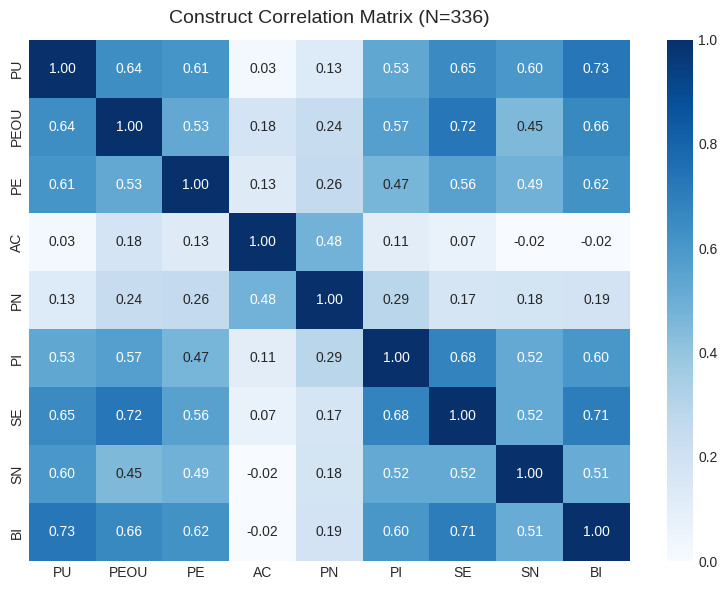

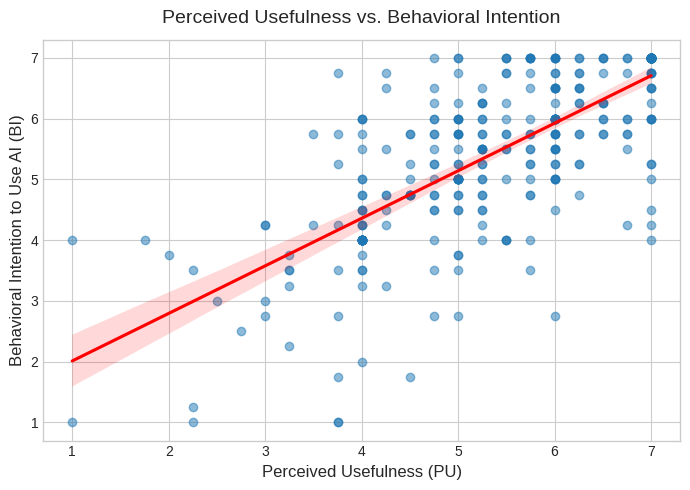

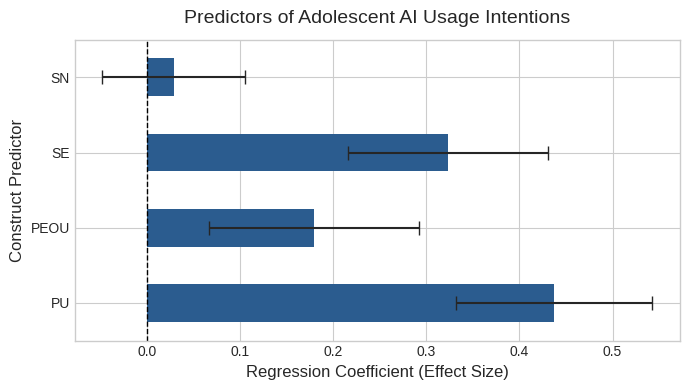

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. DATA INGESTION & FEATURE ENGINEERING
data_path = "ChatGPT-supported learning data.csv"

# Read the uploaded dataset
df = pd.read_csv(data_path, sep=r'\s+|\t|,', engine='python')

# Mapping construct prefixes to calculate composite scale scores
constructs = {
    'PU': ['PU1', 'PU2', 'PU3', 'PU4'],
    'PEOU': ['PEOU1', 'PEOU2', 'PEOU3', 'PEOU4'],
    'PE': ['PE1', 'PE2', 'PE3', 'PE4'],
    'AC': ['AC1', 'AC2', 'AC3'],
    'PN': ['PN1', 'PN2', 'PN3', 'PN4'],
    'PI': ['PI1', 'PI2', 'PI3', 'PI4'],
    'SE': ['SE1', 'SE2', 'SE3'],
    'SN': ['SN1', 'SN2', 'SN3'],
    'BI': ['BI1', 'BI2', 'BI3', 'BI4']
}

# Calculate mean score for each construct scale
scaled_df = pd.DataFrame()
for scale, items in constructs.items():
    valid_items = [col for col in items if col in df.columns]
    if valid_items:
        scaled_df[scale] = df[valid_items].mean(axis=1)

print("--- DESCRIPTIVE STATISTICS ---")
print(scaled_df.describe().round(2))

# 2. STATISTICAL MODELING (MULTIPLE REGRESSION)
X = scaled_df[['PU', 'PEOU', 'SE', 'SN']]
X = sm.add_constant(X)
y = scaled_df['BI']

model = sm.OLS(y, X).fit()

print("\n--- REGRESSION MODEL RESULTS ---")
print(model.summary())

# 3. VISUALIZATIONS
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Figure 1: Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(scaled_df.corr(), annot=True, cmap='Blues', fmt=".2f", vmin=0, vmax=1)
plt.title("Construct Correlation Matrix (N=336)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Figure 2: Perceived Usefulness vs. Behavioral Intention
plt.figure(figsize=(7, 5))
sns.regplot(data=scaled_df, x='PU', y='BI', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel("Perceived Usefulness (PU)", fontsize=12)
plt.ylabel("Behavioral Intention to Use AI (BI)", fontsize=12)
plt.title("Perceived Usefulness vs. Behavioral Intention", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Figure 3: Regression Coefficients
params = model.params.drop('const')
conf_int = model.conf_int().drop('const')
errors = conf_int[1] - params

plt.figure(figsize=(7, 4))
params.plot(kind='barh', xerr=errors, capsize=5, color='#2b5c8f')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Regression Coefficient (Effect Size)", fontsize=12)
plt.ylabel("Construct Predictor", fontsize=12)
plt.title("Predictors of Adolescent AI Usage Intentions", fontsize=14, pad=12)
plt.tight_layout()
plt.show()